In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/clean_soccer_dataset.csv", parse_dates=["date"])

df.head()

,date,year,decade,home_team,away_team,home_team_code,away_team_code,home_score,away_score,match_result,matchday_name,round,type,match_attendance,stadium_country_code,stadium_capacity
0,1958-09-28,1958,1950,USSR,Hungary,URS,HUN,3.0,1.0,H,1,ROUND_OF_16,FIRST_LEG,100572.0,RUS,81015.0
1,1958-10-01,1958,1950,France,Greece,FRA,GRE,7.0,1.0,H,1,ROUND_OF_16,FIRST_LEG,37590.0,FRA,47926.0
2,1958-11-02,1958,1950,Romania,Türki̇ye,ROU,TUR,3.0,0.0,H,1,ROUND_OF_16,FIRST_LEG,67200.0,ROU,0.0
3,1958-12-03,1958,1950,Greece,France,GRE,FRA,1.0,1.0,D,2,ROUND_OF_16,SECOND_LEG,18833.0,GRE,68224.0
4,1959-04-05,1959,1950,Republic of Ireland,Czechoslovakia,IRL,TCH,2.0,0.0,H,1,PRELIMINARY,FIRST_LEG,37500.0,IRL,2740.0


In [3]:
df.shape

(2842, 16)

In [4]:
features = [
    "home_team",
    "away_team",
    "year",
    "decade",
    "match_attendance",
    "stadium_capacity"
]

X = df[features]
y = df["match_result"]

In [ ]:
# Encode Categorical Variables

# Copy to avoid modifying original
X_encoded = X.copy()

# Encode categorical columns
categorical_cols = ["home_team", "away_team"]

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [6]:
# Train-Test Split
df_sorted = df.sort_values("date")

X_encoded = X_encoded.loc[df_sorted.index]
y = y.loc[df_sorted.index]

In [7]:
split_index = int(0.8 * len(df_sorted))

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2273, 6)
Test size: (569, 6)


In [8]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

match_result
H    0.478032
A    0.351494
D    0.170475
Name: proportion, dtype: float64

<H1>Baseline Model</H1>

In [9]:
from sklearn.linear_model import LogisticRegression

In [11]:
X_train.isnull().sum()

home_team            0
away_team            0
year                 0
decade               0
match_attendance    15
stadium_capacity     2
dtype: int64

In [12]:
X_test.isnull().sum()

home_team           0
away_team           0
year                0
decade              0
match_attendance    6
stadium_capacity    0
dtype: int64

In [13]:
# Fixing the null values issues
# Make safe copies
X_train = X_train.copy()
X_test = X_test.copy()

# Numeric columns
numeric_cols = ["year", "decade", "match_attendance", "stadium_capacity"]

# Compute medians from training set
train_medians = X_train[numeric_cols].median()

# Fill missing values
X_train.loc[:, numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test.loc[:, numeric_cols] = X_test[numeric_cols].fillna(train_medians)

In [14]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

home_team           0
away_team           0
year                0
decade              0
match_attendance    0
stadium_capacity    0
dtype: int64
home_team           0
away_team           0
year                0
decade              0
match_attendance    0
stadium_capacity    0
dtype: int64


In [15]:
# Train Logistic Regression
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = model_lr.predict(X_test)

In [17]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.5940246045694201


In [18]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.62      0.55      0.58       200
           D       0.00      0.00      0.00        97
           H       0.58      0.84      0.69       272

    accuracy                           0.59       569
   macro avg       0.40      0.46      0.42       569
weighted avg       0.50      0.59      0.53       569



c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

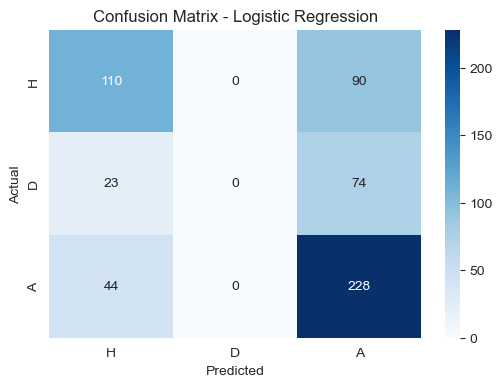

In [19]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

<H1>Decision Tree</H1>

In [20]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.4780316344463972
              precision    recall  f1-score   support

           A       0.55      0.50      0.52       200
           D       0.22      0.37      0.27        97
           H       0.61      0.50      0.55       272

    accuracy                           0.48       569
   macro avg       0.46      0.46      0.45       569
weighted avg       0.52      0.48      0.49       569



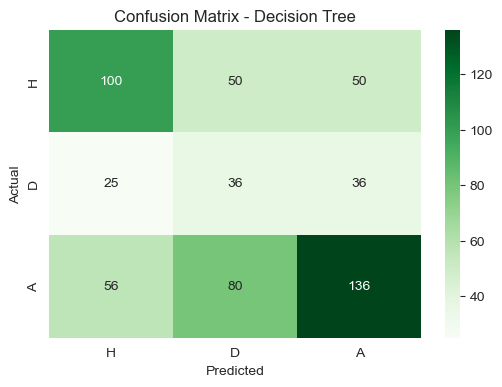

In [21]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["H", "D", "A"],
    yticklabels=["H", "D", "A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Reevluating. As I am not that happy with the result

In [22]:
model_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
y_pred_dt = model_dt.predict(X_test)

In [24]:
print("Improved Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Improved Decision Tree Accuracy: 0.5588752196836555


In [25]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           A       0.54      0.58      0.56       200
           D       0.00      0.00      0.00        97
           H       0.57      0.74      0.64       272

    accuracy                           0.56       569
   macro avg       0.37      0.44      0.40       569
weighted avg       0.46      0.56      0.51       569



c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

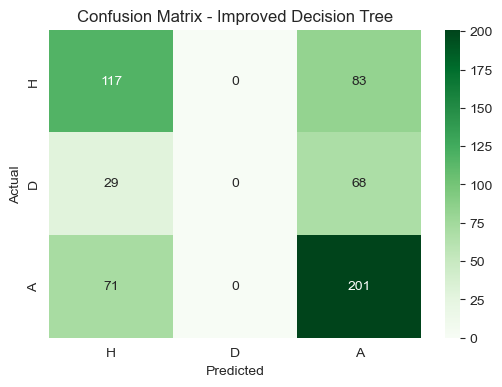

In [26]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["H","D","A"],
    yticklabels=["H","D","A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved Decision Tree")

plt.show()

While the constrained decision tree improved overall accuracy, it completely failed to predict draw outcomes. This highlights the challenge of class imbalance in soccer match prediction, where less frequent outcomes such as draws are often ignored by standard models.

In [27]:
model_dt_balanced = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

model_dt_balanced.fit(X_train, y_train)

y_pred_dt_bal = model_dt_balanced.predict(X_test)

print("Balanced Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_bal))
print(classification_report(y_test, y_pred_dt_bal))

Balanced Decision Tree Accuracy: 0.5131810193321616
              precision    recall  f1-score   support

           A       0.52      0.70      0.60       200
           D       0.20      0.21      0.21        97
           H       0.65      0.48      0.55       272

    accuracy                           0.51       569
   macro avg       0.46      0.46      0.45       569
weighted avg       0.53      0.51      0.51       569



<H1>Random Forest</H1>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Predict
y_pred_rf = model_rf.predict(X_test)

In [30]:
# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5869947275922671
              precision    recall  f1-score   support

           A       0.57      0.67      0.62       200
           D       0.27      0.12      0.17        97
           H       0.65      0.69      0.67       272

    accuracy                           0.59       569
   macro avg       0.50      0.49      0.49       569
weighted avg       0.56      0.59      0.57       569



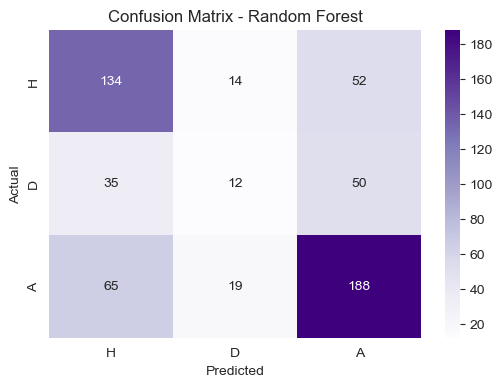

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["H","D","A"],
    yticklabels=["H","D","A"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

<H1>XGBoost</H1>

In [33]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()

y_train_enc = le_target.fit_transform(y_train)
y_test_enc = le_target.transform(y_test)

In [34]:
# Train model
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

model_xgb.fit(X_train, y_train_enc)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [35]:
# Predict
y_pred_xgb = model_xgb.predict(X_test)

In [36]:
# Evaluate 
print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))

print(classification_report(y_test_enc, y_pred_xgb))

XGBoost Accuracy: 0.648506151142355
              precision    recall  f1-score   support

           0       0.64      0.70      0.67       200
           1       0.32      0.10      0.16        97
           2       0.69      0.81      0.74       272

    accuracy                           0.65       569
   macro avg       0.55      0.54      0.52       569
weighted avg       0.61      0.65      0.62       569



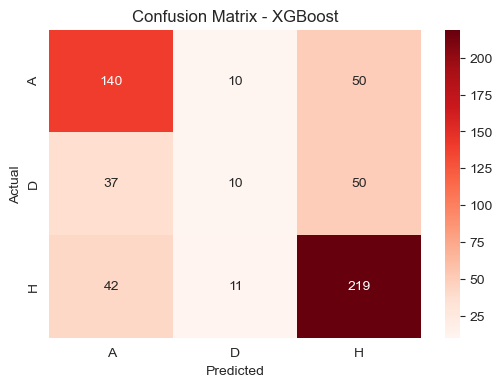

In [37]:
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["A","D","H"],
    yticklabels=["A","D","H"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()